# PFAM Annotation Module

This notebook demonstrates the use of the two main methods from the `pfam_annotation.py` module in pyMut.


## 1. Import libraries and load data


In [1]:
import matplotlib.pyplot as plt

# Import pyMut
from pyMut import read_maf
from pyMut.utils.database import build_embedded_db, connect_db

# Load example data
maf_file = "../../../src/pyMut/data/examples/MAF/tcga_laml_VEP_annotated.maf.gz"
maf_data = read_maf(maf_file,assembly="37")

# Configure PFAM database
try:
    build_embedded_db(force_rebuild=False)
except:
    pass


2025-10-12 09:03:18,672 | INFO | pyMut.input | Starting MAF reading: ../../../src/pyMut/data/examples/MAF/tcga_laml_VEP_annotated.maf.gz
2025-10-12 09:03:18,676 | INFO | pyMut.input | Reading MAF with 'pyarrow' engine…
2025-10-12 09:03:18,697 | INFO | pyMut.input | Reading with 'pyarrow' completed.
2025-10-12 09:03:18,704 | INFO | pyMut.input | Detected 193 unique samples.
2025-10-12 09:03:18,793 | INFO | pyMut.input | Consolidating duplicate variants across samples...
2025-10-12 09:03:18,806 | INFO | pyMut.input | Consolidating variants using vectorized operations...
2025-10-12 09:04:11,594 | INFO | pyMut.input | Variant consolidation completed in 52.80 seconds
2025-10-12 09:04:11,600 | INFO | pyMut.input | Consolidated 2207 rows into 2091 unique variants
2025-10-12 09:04:11,612 | INFO | pyMut.input | Saving to cache: ../../../src/pyMut/data/examples/MAF/.pymut_cache/tcga_laml_VEP_annotated.maf_b8cb1ccd352377b7.parquet
2025-10-12 09:04:11,675 | INFO | pyMut.input | MAF processed succe

✅ Database already exists at /home/luisruimore/Escritorio/TFG/src/pyMut/data/resources/data.duckdb


## 2. Using the annotate_pfam() method


In [2]:
# Annotate variants with PFAM domains
maf_data = maf_data.annotate_pfam()

# Show annotation examples
if 'pfam_id' in maf_data.data.columns:
    pfam_examples = maf_data.data[
        maf_data.data['pfam_id'].notna()
    ][['Hugo_Symbol', 'Protein_Change', 'uniprot', 'aa_pos', 'pfam_id', 'pfam_name']].head(10)
    display(pfam_examples)


2025-10-12 09:04:18,487 | INFO | pyMut.analysis.pfam_annotation | UniProt resolution summary:
2025-10-12 09:04:18,487 | INFO | pyMut.analysis.pfam_annotation |    Total identifiers processed: 1,552
2025-10-12 09:04:18,487 | INFO | pyMut.analysis.pfam_annotation |    Direct accessions: 0
2025-10-12 09:04:18,488 | INFO | pyMut.analysis.pfam_annotation |    Resolved via short_name: 1,474
2025-10-12 09:04:18,488 | INFO | pyMut.analysis.pfam_annotation |    Resolved via external ID: 0
2025-10-12 09:04:18,489 | INFO | pyMut.analysis.pfam_annotation |    Unresolved: 78
2025-10-12 09:04:19,317 | INFO | pyMut.analysis.pfam_annotation | Variantes anotadas con PFAM: 1033/1843
2025-10-12 09:04:19,820 | INFO | pyMut.analysis.pfam_annotation | 
Final annotation summary:
2025-10-12 09:04:19,821 | INFO | pyMut.analysis.pfam_annotation |    Total variants processed: 2,091
2025-10-12 09:04:19,822 | INFO | pyMut.analysis.pfam_annotation |    UniProt identifiers resolved: 1,474/1,552
2025-10-12 09:04:19,8

,Hugo_Symbol,Protein_Change,uniprot,aa_pos,pfam_id,pfam_name
0,KIAA1529,p.T431T,CC180_HUMAN,431.0,PF00028,PF00028
1,KIAA1529,p.R581H,CC180_HUMAN,581.0,PF00028,PF00028
2,TBC1D2,p.L593R,TBD2A_HUMAN,593.0,PF00028,PF00028
3,LPPR1,p.T325I,LPPR1_HUMAN,325.0,PF00028,PF00028
4,BAAT,p.T376M,BAAT_HUMAN,376.0,PF00028,PF00028
5,FKTN,<NA>,FKTN_HUMAN,NaN,PF00048,PF00048
6,ZNF462,p.R1680C,ZN462_HUMAN,1680.0,PF00048,PF00048
7,ACTL7A,p.G426R,ACL7A_HUMAN,426.0,PF00048,PF00048
8,UGCG,p.Y47Y,CEGT_HUMAN,47.0,PF00049,PF00049
9,C9orf43,p.T181A,CI043_HUMAN,181.0,PF00051,PF00051


## 2.1 PFAM annotation coverage statistics

This block summarizes the percentage of variants that received a PFAM annotation.


In [3]:
# Compute annotation coverage
total_variants = len(maf_data.data) if hasattr(maf_data, 'data') else 0
annotated_variants = 0
if total_variants > 0 and 'pfam_id' in maf_data.data.columns:
    annotated_variants = maf_data.data['pfam_id'].notna().sum()

coverage_pct = (annotated_variants / total_variants * 100) if total_variants > 0 else 0.0

print(f"PFAM annotation coverage: {annotated_variants}/{total_variants} ({coverage_pct:.1f}%)")

# If available, also show UniProt resolution stats from metadata
try:
    pfam_stats = getattr(getattr(maf_data, 'metadata', None), 'pfam_resolution_stats', None)
    if isinstance(pfam_stats, dict) and 'total' in pfam_stats and 'unresolved' in pfam_stats:
        resolved = pfam_stats['total'] - pfam_stats['unresolved']
        res_pct = (resolved / pfam_stats['total'] * 100) if pfam_stats['total'] else 0.0
        print(f"UniProt identifiers resolved: {resolved}/{pfam_stats['total']} ({res_pct:.1f}%)")
except Exception as e:
    pass


PFAM annotation coverage: 1033/2091 (49.4%)
UniProt identifiers resolved: 1474/1552 (95.0%)


## 3. Using the pfam_domains() method


,pfam_id,pfam_name,n_genes,n_variants
405,PF13853,PF13853,6,28
32,PF00071,PF00071,20,21
15,PF00028,PF00028,19,20
31,PF00069,PF00069,17,19
0,PF00001,PF00001,13,18
18,PF00041,PF00041,14,16
327,PF07714,PF07714,13,16
105,PF00520,PF00520,13,15
155,PF00870,PF00870,12,14
43,PF00096,PF00096,13,14


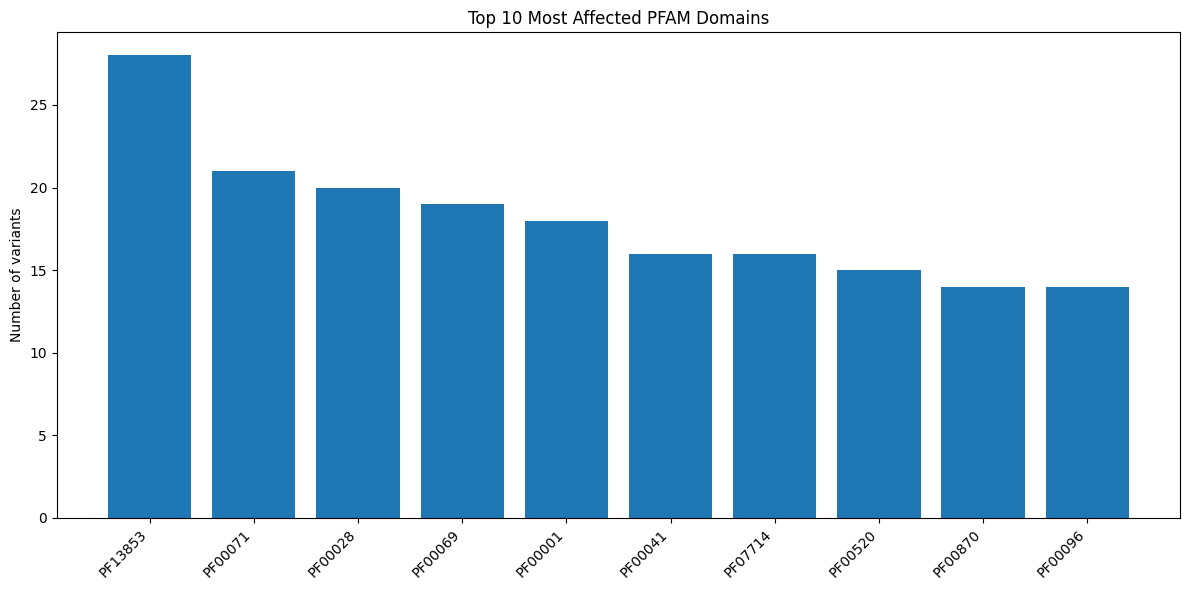

,uniprot,aa_pos,pfam_id,pfam_name,n_variants,n_genes
395,IDHC_HUMAN,132.0,PF00145,PF00145,3,1
248,DNM3A_HUMAN,729.0,PF13853,PF13853,2,1
244,DNM3A_HUMAN,615.0,PF13853,PF13853,2,1
691,RASK_HUMAN,12.0,PF00001,PF00001,2,1
671,PTN11_HUMAN,510.0,PF07716,PF07716,2,1
396,IDHP_HUMAN,140.0,PF12796,PF12796,2,1
635,PKHH1_HUMAN,620.0,PF00595,PF00595,1,1
639,PLCE1_HUMAN,696.0,PF13855,PF13855,1,1
638,PLCE1_HUMAN,584.0,PF22930,PF22930,1,1
637,PLCE1_HUMAN,238.0,PF12796,PF12796,1,1


In [4]:
# Summary by PFAM domain
pfam_summary = maf_data.pfam_domains(
    summarize_by='PfamDomain',
    top_n=10,
    include_synonymous=False
)

if not pfam_summary.empty:
    display(pfam_summary)

    # Visualization
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(pfam_summary)), pfam_summary['n_variants'])
    plt.xticks(range(len(pfam_summary)), pfam_summary['pfam_name'], rotation=45, ha='right')
    plt.ylabel('Number of variants')
    plt.title('Top 10 Most Affected PFAM Domains')
    plt.tight_layout()
    plt.show()

# Summary by amino acid position
aa_summary = maf_data.pfam_domains(
    summarize_by='AAPos',
    top_n=10,
    include_synonymous=False
)

if not aa_summary.empty:
    display(aa_summary)


In [5]:
# Try to build the embedded database
print("Setting up PFAM database...")
try:
    # This will create the database if it doesn't exist
    build_embedded_db(force_rebuild=False)
    print("✓ PFAM database configured successfully")
except Exception as e:
    print(f"⚠️  Error setting up database: {e}")
    print("We will continue with available functions...")

# Try to connect to the database
try:
    db_conn = connect_db()
    print("✓ Database connection established")

    # Check available tables
    tables = db_conn.execute("SHOW TABLES").fetchall()
    print(f"Available tables: {[table[0] for table in tables]}")

    db_conn.close()
except Exception as e:
    print(f"⚠️  Error connecting to database: {e}")
    db_conn = None

Setting up PFAM database...
✅ Database already exists at /home/luisruimore/Escritorio/TFG/src/pyMut/data/resources/data.duckdb
✓ PFAM database configured successfully
✓ Database connection established
Available tables: ['meta', 'pfam', 'xref']
